<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Face_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mediapipe deepface opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
import mediapipe as mp
from deepface import DeepFace

# Load target face
target_img = cv2.imread("Trump_2025.jpg")

# Mediapipe face detector
mp_face = mp.solutions.face_detection
face_detector = mp_face.FaceDetection(model_selection=0, min_detection_confidence=0.5)

In [ ]:
def get_face_crop(image, detection):
    h, w, _ = image.shape
    bbox = detection.location_data.relative_bounding_box

    x1 = int(bbox.xmin * w)
    y1 = int(bbox.ymin * h)
    x2 = int((bbox.xmin + bbox.width) * w)
    y2 = int((bbox.ymin + bbox.height) * h)

    # ensure valid bounds
    x1 = max(x1, 0)
    y1 = max(y1, 0)
    x2 = min(x2, w)
    y2 = min(y2, h)

    return image[y1:y2, x1:x2]

In [ ]:
def is_match(face1, face2, threshold=0.5):
    try:
        result = DeepFace.verify(face1, face2, model_name='Facenet', enforce_detection=False)
        return result['distance'] < threshold
    except:
        return False

In [ ]:
# !ls /content/drive/MyDrive

In [ ]:
video_path = "/content/drive/MyDrive/Trump_Air_Force_One.mp4"
video_to_use = cv2.VideoCapture(video_path)

fps = video_to_use.get(cv2.CAP_PROP_FPS)

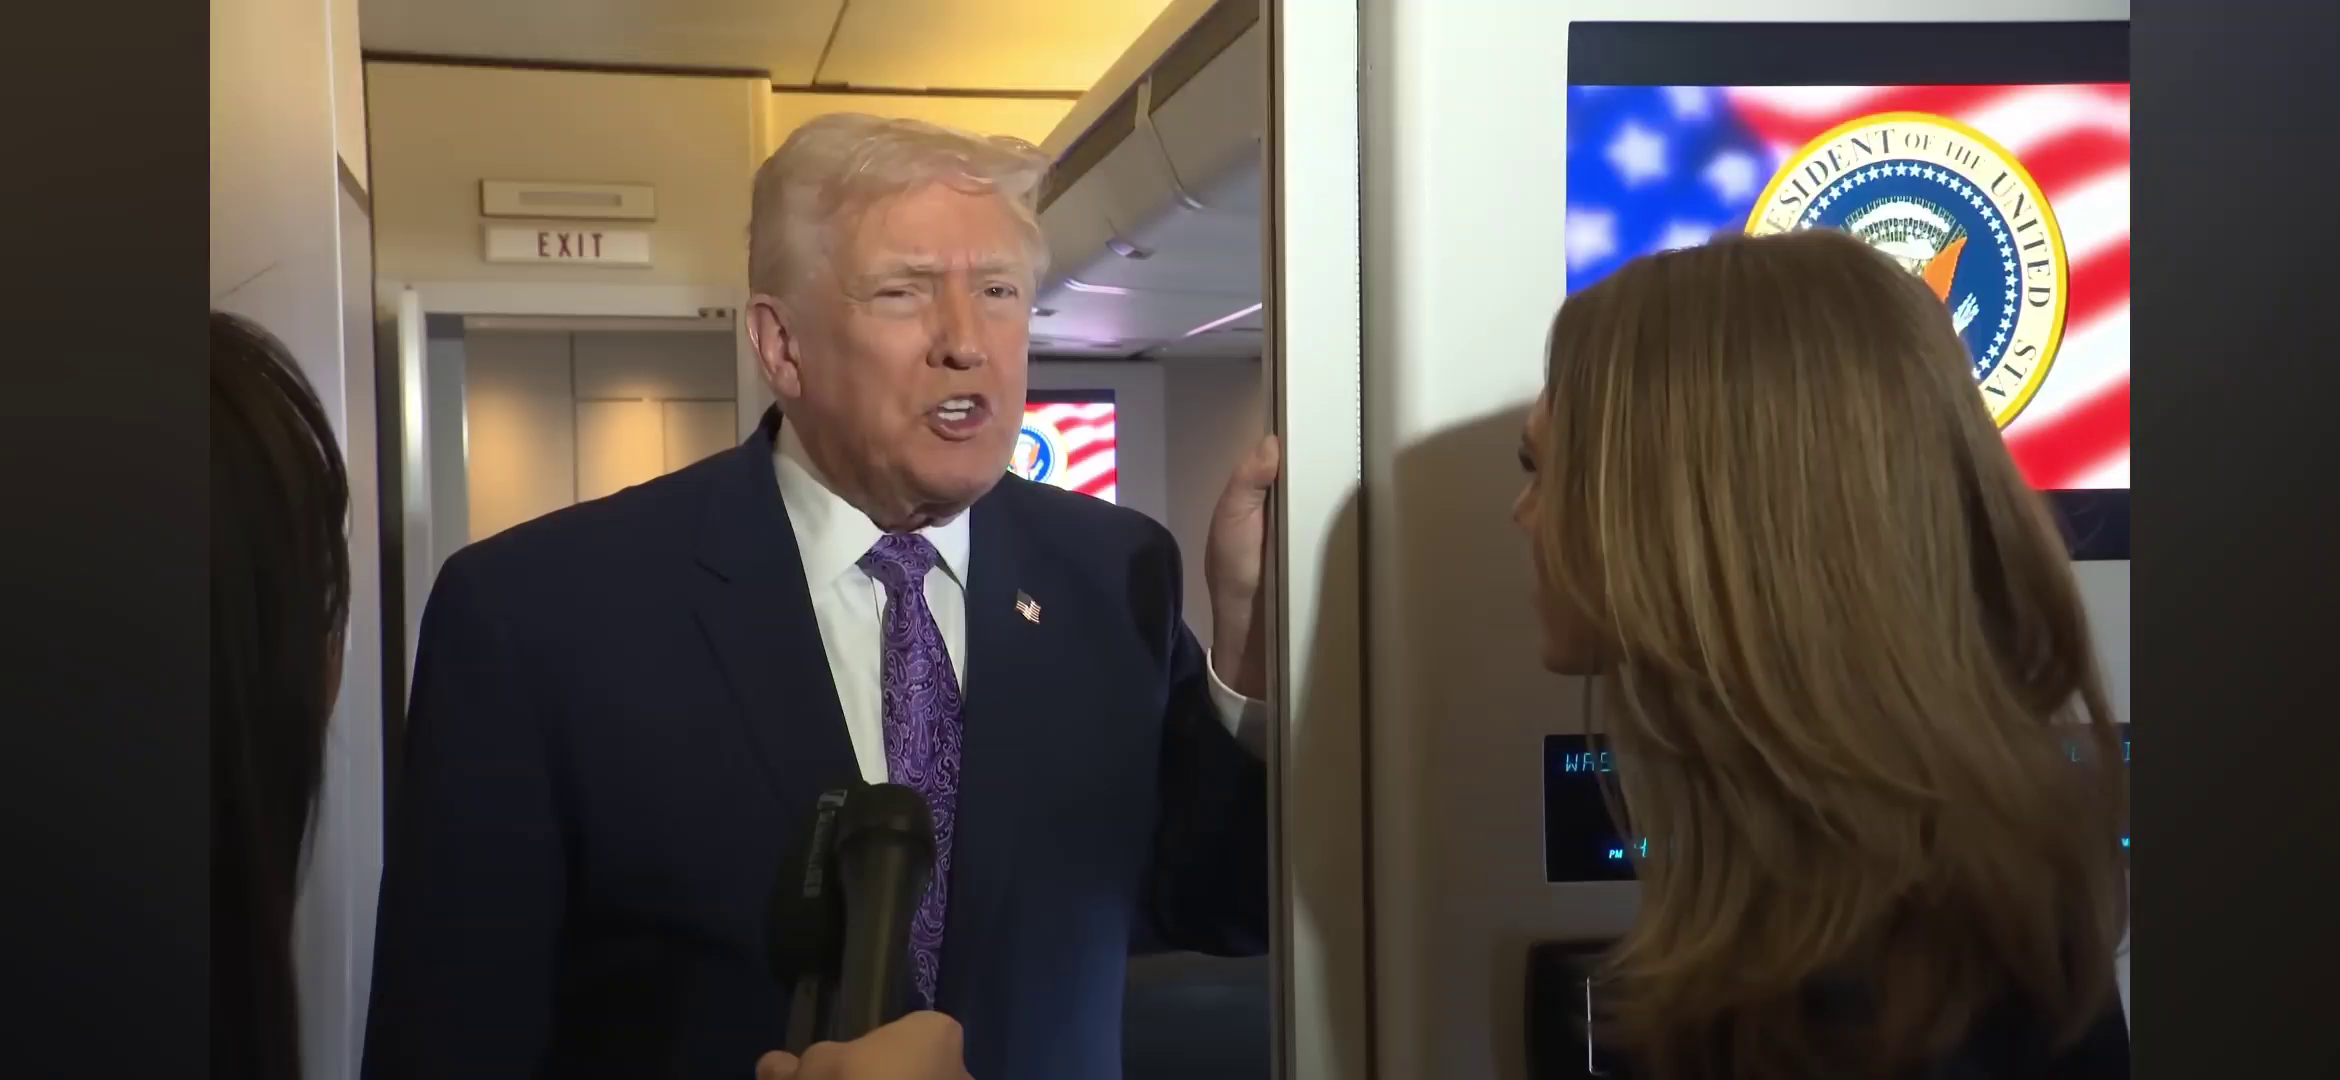

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()
if ret:
    cv2_imshow(frame)
else:
    print("Could not read video.")

cap.release()

In [ ]:
import cv2

video = cv2.VideoCapture("/content/drive/MyDrive/Trump_Air_Force_One.mp4")
fps = video.get(cv2.CAP_PROP_FPS)

frame_num = 0
matches = []

while True:
    ret, frame = video.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_detector.process(rgb)

    if results.detections:
        for det in results.detections:
            face_crop = get_face_crop(frame, det)

            if face_crop.size > 0 and is_match(target_img, face_crop):
                timestamp = frame_num / fps
                matches.append(timestamp)
                print(f"Match found at {timestamp:.2f} seconds!")

    frame_num += 1

video.release()

print("Done scanning video.")
print("Matches:", matches)

25-12-04 20:20:59 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:01<00:00, 69.6MB/s]


Match found at 0.00 seconds!
Match found at 0.02 seconds!
Match found at 0.04 seconds!
Match found at 0.07 seconds!
Match found at 0.09 seconds!
Match found at 0.11 seconds!
Match found at 0.13 seconds!
Match found at 0.15 seconds!
Match found at 0.17 seconds!
Match found at 0.20 seconds!
Match found at 0.22 seconds!
Match found at 0.24 seconds!
Match found at 0.26 seconds!
Match found at 0.28 seconds!
Match found at 0.30 seconds!
Match found at 0.37 seconds!
Match found at 0.39 seconds!
Match found at 0.41 seconds!
Match found at 0.43 seconds!
Match found at 0.46 seconds!
Match found at 0.48 seconds!
Match found at 0.50 seconds!
Match found at 0.52 seconds!
Match found at 0.54 seconds!
Match found at 0.56 seconds!
Match found at 0.85 seconds!
Match found at 0.87 seconds!
Match found at 0.89 seconds!
Match found at 0.91 seconds!
Match found at 0.93 seconds!
Match found at 0.95 seconds!
Match found at 0.98 seconds!
Match found at 1.00 seconds!
Match found at 1.02 seconds!
Match found at